In [11]:
import numpy as np
import matplotlib.pyplot as plt

from k_means_clustering import KMeansClustering

In [12]:
from sklearn.datasets import make_blobs

m = 500
k = 3

X, y_true = make_blobs(
    n_samples=m,
    centers=k,
    cluster_std=1.2,
    random_state=42
)

print("X shape:", X.shape)

X shape: (500, 2)


In [13]:
model = KMeansClustering()
model.fit(X)

labels = model.predict(X)
centroids = np.array(model.centroids)

print("Centroids:")
print(centroids)

Centroids:
[[ 4.60901939  1.92357473]
 [-2.51420417  9.03905718]
 [-6.82151458 -6.73186861]]


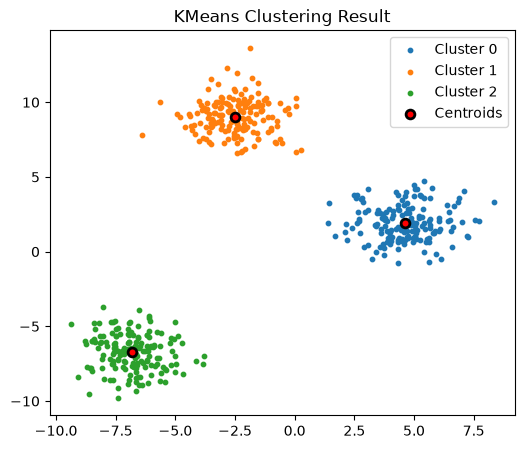

In [14]:
plt.figure(figsize=(6, 5))

for i in range(model.k):
    pts = X[labels == i]
    plt.scatter(pts[:, 0], pts[:, 1], s=10, label=f"Cluster {i}")

centroids = np.array(model.centroids)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=40, marker='o', label='Centroids', edgecolors='black', linewidths=2)

plt.title("KMeans Clustering Result")
plt.legend()
plt.show()

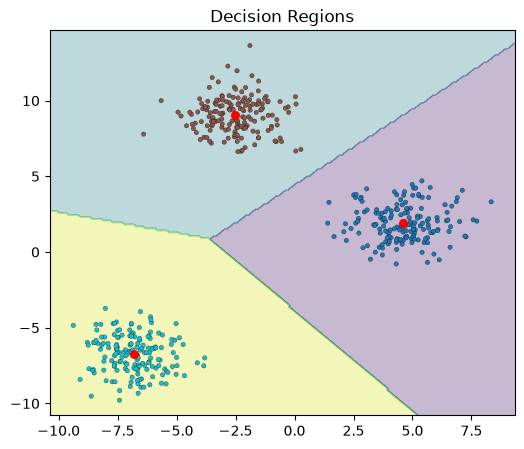

In [15]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap="tab10", edgecolor="k", linewidth=0.2)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=30, marker='o')
plt.title("Decision Regions")
plt.show()

I get diff k on each run because the class uses random initialization, so the inertia values change each run, and the elbow heuristic is sensitive to those small variations, so it picks a different k.